In [9]:
import json
import matplotlib.pyplot as plt
import numpy as np
from typing import Any

def load_event_history(filepath: str, trial: int = 0) -> dict[str, list[int]]:
    """JSONLファイル（jsonl_trials / jsonl_trials_dict）から指定trialのイベント履歴を読み込む"""
    with open(filepath, "r", encoding="utf-8") as f:
        data = [json.loads(line) for line in f]

    if trial < 0 or trial >= len(data):
        raise IndexError(f"trial={trial} is out of range (0..{len(data)-1})")

    trial_data = data[trial]
    events = trial_data.get("events", {})

    # dict形式: {"name":[...], ...}
    if isinstance(events, dict):
        return {str(k): list(map(int, v)) for k, v in events.items()}

    # list形式: [["name",[...]], ...]
    if isinstance(events, list):
        out: dict[str, list[int]] = {}
        for e in events:
            if not (isinstance(e, (list, tuple)) and len(e) == 2):
                continue
            name, steps = e
            out[str(name)] = list(map(int, steps)) if steps is not None else []
        return out

    raise ValueError("Unsupported events format in JSONL (expected dict or list).")


def plot_cumulative_events(
    event_source: Any,
    event_names: list[str] | None = None,
    figsize: tuple[int, int] = (12, 6),
    title: str = "Event Firing History",
    xlim: tuple[int, int] | None = None,
    *,
    trial: int = 0,
):
    """
    イベント発火の累積回数をプロット（既存互換を維持しつつtrial指定に対応）

    互換動作:
      - event_source が dict {event_name:[steps...]} の場合: 従来通りそのdictを描画（trialは無視）
    追加動作:
      - event_source が str（filepath）の場合: JSONLから trial を読み込んで描画

    Args:
        event_source: dict もしくは jsonl filepath（str）
        event_names: プロットするイベント名（Noneなら全イベント）
        trial: jsonl filepath を渡した場合に描画する trial
    """
    # --- 入力の吸収（互換維持の要点）---
    if isinstance(event_source, str):
        event_dict = load_event_history(event_source, trial=trial)
        auto_title = f"{title} (trial={trial})"
    elif isinstance(event_source, dict):
        event_dict = event_source
        auto_title = title
    else:
        raise TypeError("event_source must be either dict or filepath (str).")

    fig, ax = plt.subplots(figsize=figsize)

    if event_names is None:
        event_names = list(event_dict.keys())

    for event_name in event_names:
        if event_name not in event_dict:
            print(f"Warning: '{event_name}' not found")
            continue

        steps = event_dict[event_name]
        if not steps:
            continue

        steps_sorted = np.sort(np.asarray(steps, dtype=np.int64))
        cumulative = np.arange(1, len(steps_sorted) + 1, dtype=np.int64)
        ax.step(steps_sorted, cumulative, where="post", label=event_name)

    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Firings")
    ax.set_title(auto_title)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.grid(True, alpha=0.3)

    if xlim is not None:
        ax.set_xlim(xlim)

    plt.tight_layout()
    plt.show()


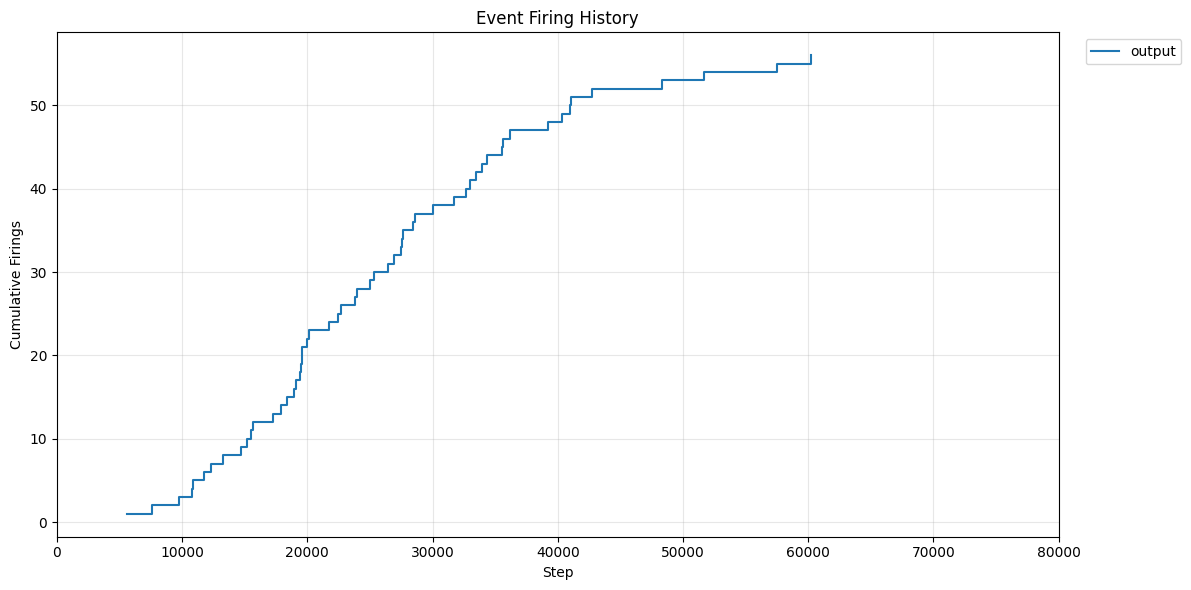

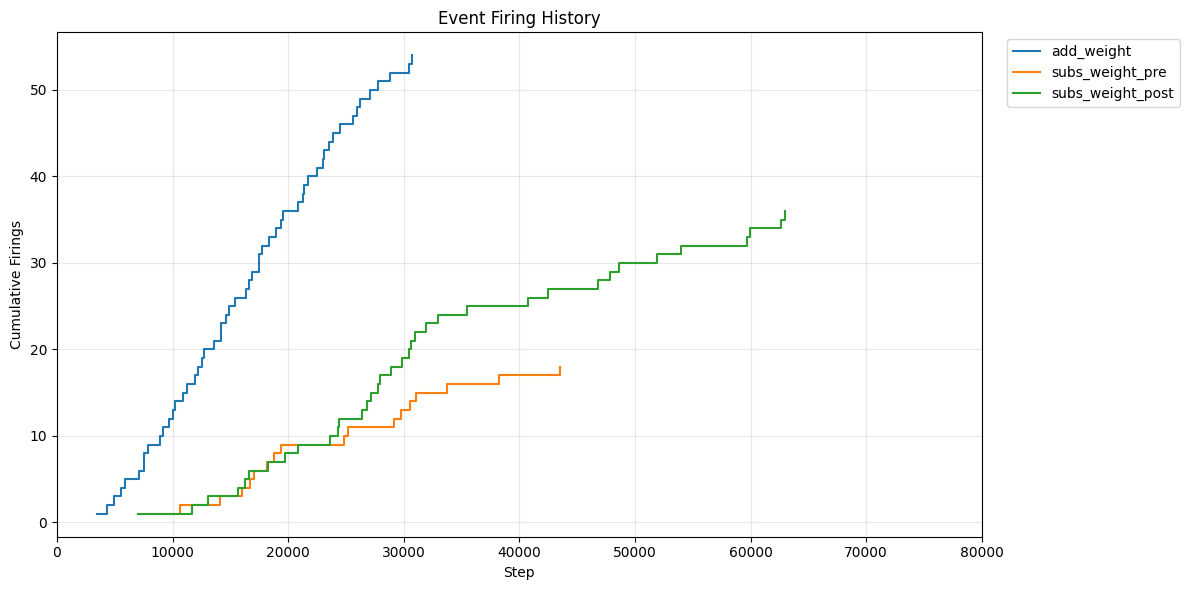

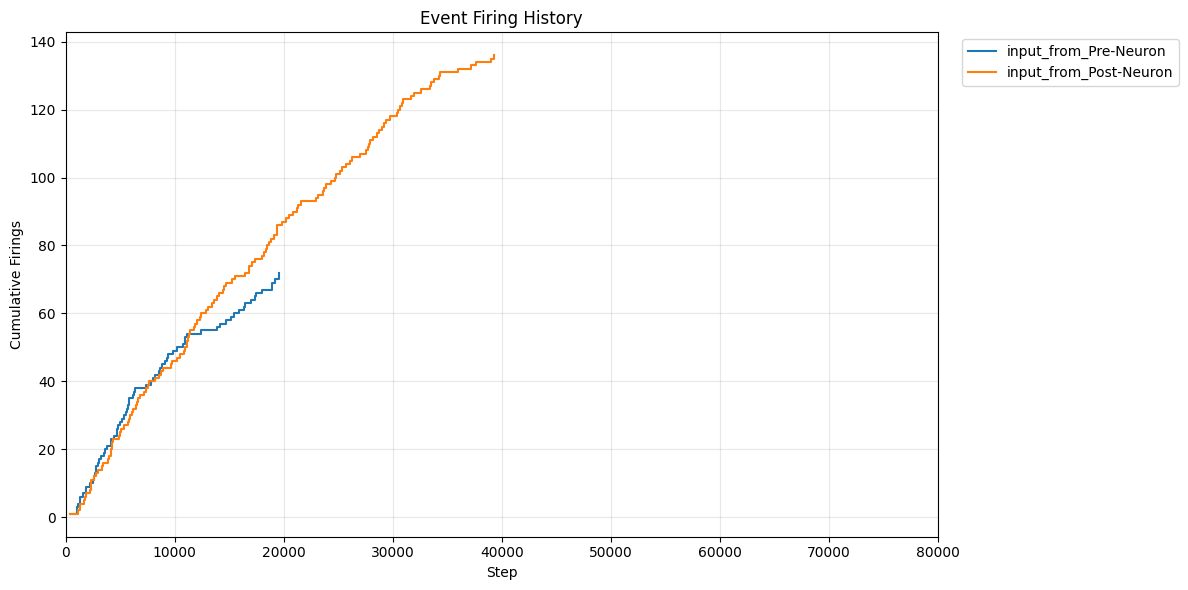

In [10]:
event_dict = load_event_history("event_history.jsonl", trial=0)

plot_cumulative_events(event_dict, event_names=["output"], xlim=(0, 80_000))
plot_cumulative_events(event_dict, event_names=["add_weight", "subs_weight_pre", "subs_weight_post"], xlim=(0, 80_000))
plot_cumulative_events(event_dict, event_names=["input_from_Pre-Neuron", "input_from_Post-Neuron"], xlim=(0, 80_000))

In [11]:
event_dict = load_event_history("event_history.jsonl", trial=1)

plot_cumulative_events(event_dict, event_names=["output"], xlim=(0, 80_000))
plot_cumulative_events(event_dict, event_names=["add_weight", "subs_weight_pre", "subs_weight_post"], xlim=(0, 80_000))
plot_cumulative_events(event_dict, event_names=["input_from_Pre-Neuron", "input_from_Post-Neuron"], xlim=(0, 80_000))

IndexError: trial=1 is out of range (0..0)